In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sampadasovitkar/customer-churn-analysis-and-retention-strategy/Telco-Customer-Churn.csv


In [3]:
import os

os.listdir('/kaggle/input/datasets/sampadasovitkar/customer-churn-analysis-and-retention-strategy')

['Telco-Customer-Churn.csv']

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sampadasovitkar/customer-churn-analysis-and-retention-strategy/Telco-Customer-Churn.csv', encoding='latin1')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df['Churn'].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [12]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [13]:
df['Churn'].mean()

np.float64(0.26578498293515357)

In [14]:
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

In [15]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

In [16]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [17]:
df.groupby('InternetService')['Churn'].mean()

InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn, dtype: float64

In [18]:
import matplotlib.pyplot as plt

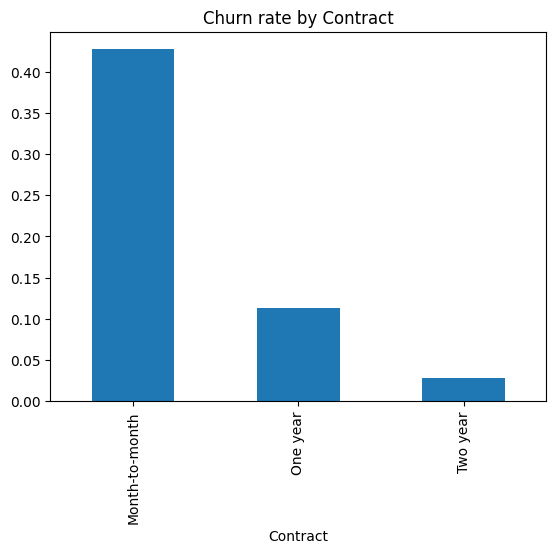

In [19]:
df.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title('Churn rate by Contract')
plt.show()

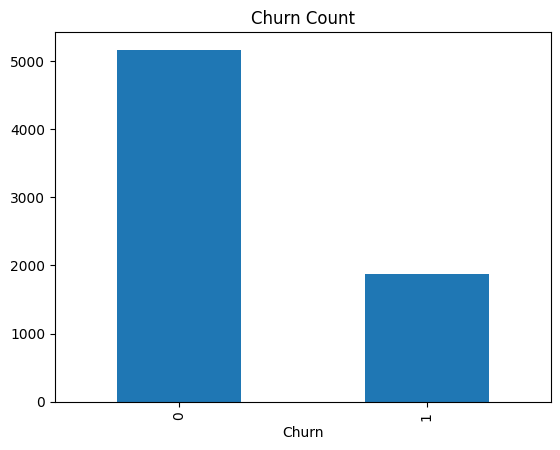

In [20]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Count')
plt.show()

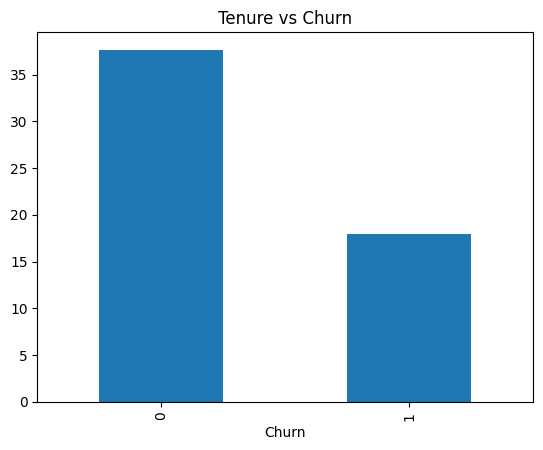

In [21]:
df.groupby('Churn')['tenure'].mean().plot(kind='bar')
plt.title('Tenure vs Churn')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [23]:
X = df[['tenure','MonthlyCharges','TotalCharges']]
y = df['Churn']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [25]:
model.score(X_test, y_test)

0.7860696517412935

In [26]:
df['Churn'].value_counts()
df.groupby('Contract')['Churn'].mean()
df.groupby('Churn')['MonthlyCharges'].mean()
df.groupby('Churn')['tenure'].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [28]:
df_clean = df.dropna()

df_clean.to_csv('cleaned_data.csv', index=False)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  